In [2]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
base_folder = 'DataScience'
location_base = os.path.join(os.getcwd().split(base_folder)[0], base_folder)
location_module = [os.path.join(location_base, 'Module')] 
for each in location_module:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

from import_KK import *
# DeviceStrategy_CPU()
DeviceStrategy_GPU()
from preprocessing_KK import *
from preprocessing_project_KK import *
from description_KK import *
from algorithm_machinelearning_KK import *
from algorithm_deeplearning_KK import *
from evaluation_KK import *
from visualization_KK import *


=========== GPU Strategy ===========
Detected GPUs:
 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TF using MirroredStrategy with 2 GPUs:
 ['/GPU:0', '/GPU:1']


======= GPU / CUDA / STATUS ========
Cuda Ready?        True
CUDA Version:      12.5.1
cuDNN Version:     9

TF Version:        2.19.0
Keras Version:     3.10.0
True
Torch Version:       2.7.1+cu126
Torch CUDA Version:  12.6
Torch cuDNN Version: 90501

Torch GPUs Available: 2
Use the GPU: NVIDIA GeForce RTX 3090



In [3]:
import plotly.graph_objects as go
import os
import pandas as pd

def plot_line(df, title='Line Plot', x_title='Date', y_title='Count',
              save_local=True, save_name='lineplot.png',
              name_map=None, color_map=None, style_map=None,
              legend_pos='top_left'): # legend_pos 인자 추가
    
    # Date 처리를 위해 인덱스가 datetime 형식이 아닐 경우 변환 시도
    if not pd.api.types.is_datetime64_any_dtype(df.index):
        try:
            df.index = pd.to_datetime(df.index)
        except:
            pass
    fig = go.Figure()

    # 데이터 Trace 추가 (이전과 동일)
    for col in df.columns:
        trace_name = name_map.get(col, col) if name_map else col
        line_color = color_map.get(col, None) if color_map else None
        line_dash = style_map.get(col, 'solid') if style_map else 'solid'
        fig.add_trace(go.Scatter(
            x=df.index, y=df[col], mode='lines', name=trace_name,
            line=dict(color=line_color, dash=line_dash)
        ))      

    # Legend 위치 설정 로직
    # 기본값: 그래프 바깥 오른쪽 (Plotly 기본)
    legend_setting = {} 
    if legend_pos == 'top_left':
        legend_setting = dict(
            yanchor="top", y=0.99,   # 상단
            xanchor="left", x=0.01,  # 왼쪽
            bgcolor='rgba(255, 255, 255, 0.7)', # 흰색 배경 (70% 불투명)
            bordercolor="Black", borderwidth=1  # 테두리 (선택사항)
        )
    elif legend_pos == 'top_right':
        legend_setting = dict(
            yanchor="top", y=0.99,
            xanchor="right", x=0.99,
            bgcolor='rgba(255, 255, 255, 0.7)'
        )
    elif legend_pos == 'bottom_right':
        legend_setting = dict(
            yanchor="bottom", y=0.01,
            xanchor="right", x=0.99,
            bgcolor='rgba(255, 255, 255, 0.7)'
        )
    elif legend_pos == 'top_center_horizontal':
        legend_setting = dict(
            orientation="h",       # 가로 배치
            yanchor="bottom", y=1.02, # 그래프 바로 위
            xanchor="right", x=1
        )

    # Layout 설정
    fig.update_layout(
        xaxis_title=x_title, yaxis_title=y_title,
        width=1000, height=600,
        title=dict(text=title, font=dict(size=25, color='black')),
        font=dict(size=20),
        legend_font_size=20,
        template='plotly_white',
        # 여기서 legend 설정을 적용합니다.
        legend=legend_setting 
    )

    # X축 설정 (이전과 동일)
    fig.update_xaxes(
        tickangle=-35, tickfont=dict(size=20), ticks='outside', showgrid=False,
        tickformat="%Y-%m", dtick="M1"
    )
    fig.update_yaxes(showgrid=True)
    fig.show()

    # Save
    if save_local:
        folder_location = os.path.join(os.getcwd(), 'Result', 'Lineplot')
        os.makedirs(folder_location, exist_ok=True)
        save_path = os.path.join(folder_location, save_name)
        # fig.write_image(save_path, engine='kaleido')
        print(f"Saved to {save_path}")

# Result (Correlation)

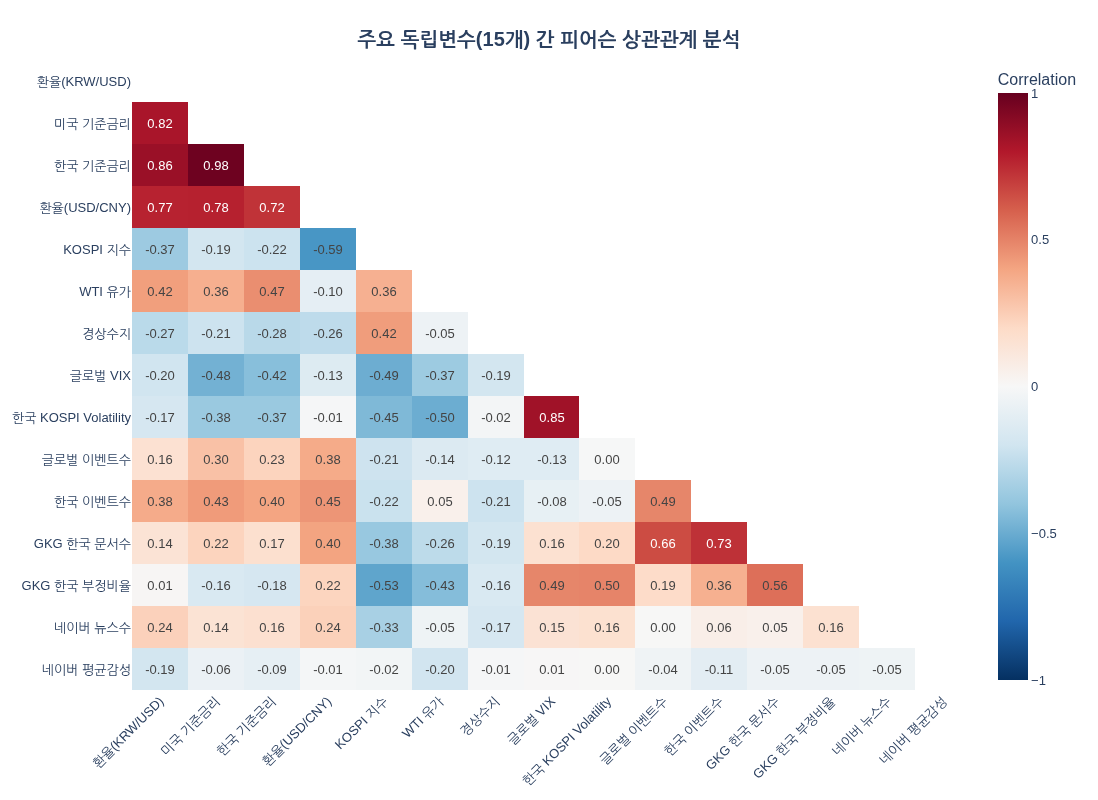

In [51]:
# Data Loading
file_location = os.path.join('.', 'data', 'df_final_2026_with_gdelt_and_news.csv')
df = pd.read_csv(file_location)

# 2. 논문에 실을 15개의 핵심 변수 선택
cols = [
    'USD_KRW 종가', 
    '미국 정책금리', '한국 정책금리', 
    'usd_cny', 'KOSPI 종가',
    'WTI Price', '경상수지',
    'vix', 'ksvkospi 종가',
    'events_total_cnt', 'events_kr_cnt',
    'gkg_kr_doc_cnt', 'gkg_kr_neg_ratio', 
    'news_total', 'sent_mean'
]

# 3. 논문 표기를 위한 깔끔한 한글 이름 매핑
rename_dict = {
    'USD_KRW 종가': '환율(KRW/USD)',
    '미국 정책금리': '미국 기준금리',
    '한국 정책금리': '한국 기준금리',
    'usd_cny': '환율(USD/CNY)',
    'KOSPI 종가': 'KOSPI 지수',
    'WTI Price': 'WTI 유가',
    '경상수지': '경상수지',
    'vix': '글로벌 VIX',
    'ksvkospi 종가': '한국 KOSPI Volatility',
    'events_total_cnt': '글로벌 이벤트수',
    'events_kr_cnt': '한국 이벤트수',
    'gkg_kr_doc_cnt': 'GKG 한국 문서수',
    'gkg_kr_neg_ratio': 'GKG 한국 부정비율',
    'news_total': '네이버 뉴스수',
    'sent_mean': '네이버 평균감성'
}

# 데이터 필터링 및 이름 변경
subset_df = df[cols].rename(columns=rename_dict).dropna()

# 피어슨 상관계수 계산
corr = subset_df.corr(method="pearson")

# 4. 하단 삼각형(Lower Triangle)만 남기기 (상단은 NaN으로 처리)
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = corr.mask(mask)

# 5. Plotly 시각화 그리기
fig = px.imshow(
    corr_masked,
    text_auto=".2f",                 # 칸 안에 상관계수 숫자 표시 (소수점 2자리)
    aspect="auto",
    color_continuous_scale="RdBu_r", # 파란색(양) ~ 빨간색(음) 색상맵 적용
    zmin=-1, zmax=1,                 # 색상 스케일을 -1부터 1까지 고정
    labels=dict(color="Correlation")
)

# 6. 레이아웃 및 폰트, 디자인 세부 설정
fig.update_layout(
    title=dict(
        text="<b>주요 독립변수(15개) 간 피어슨 상관관계 분석</b>",
        font=dict(size=20),
        x=0.5, # 타이틀을 표의 정중앙으로 배치
        y=0.96
    ),
    width=900,   # 표의 가로 길이
    height=800,  # 표의 세로 길이
    xaxis=dict(tickangle=-45, side="bottom"), # x축 텍스트 45도 기울이기
    # Plotly 폰트 설정 (웹 기본 폰트를 사용해 한글 깨짐 원천 차단)
    font=dict(family="Arial, 'Malgun Gothic', 'AppleGothic', sans-serif", size=13),
    plot_bgcolor='white',  # 배경색 하얗게
    paper_bgcolor='white'
)

# NaN으로 처리된 빈 공간(상단 삼각형)의 선을 없애서 깔끔하게 만듦
fig.update_xaxes(showgrid=False, zeroline=False)
fig.update_yaxes(showgrid=False, zeroline=False)

# 화면에 출력
fig.show()

# (선택사항) 인터랙티브 HTML 파일로 저장하기
# fig.write_html("correlation_heatmap_15vars.html")

# Result (Prediction)

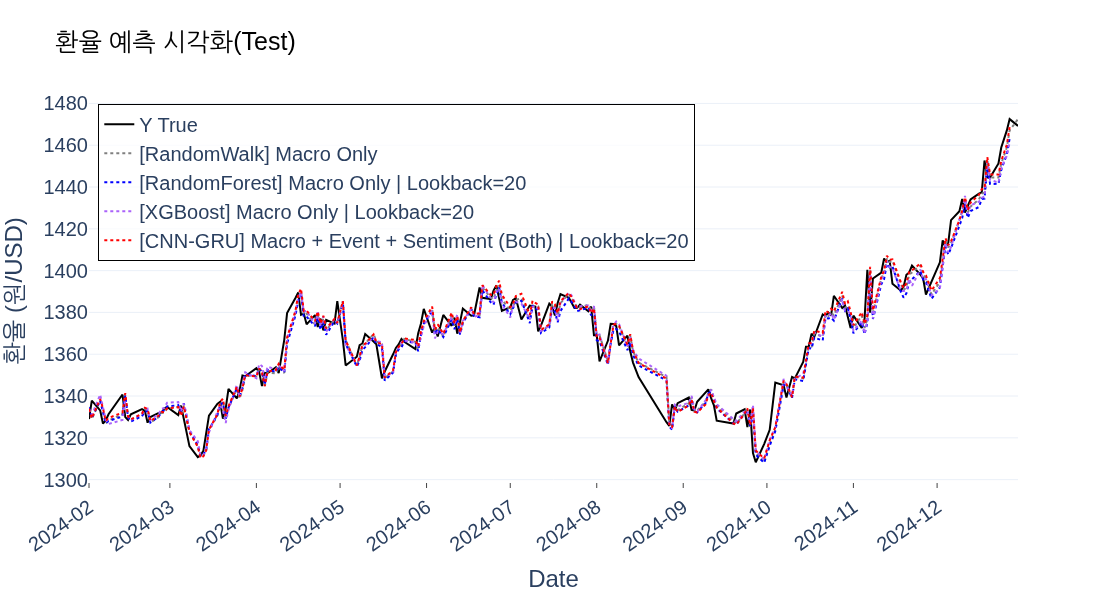

In [27]:
# Data Loading
file_location = os.path.join('.', 'Result', 'Prediction_KK.csv')
df = pd.read_csv(file_location)
# Filtering
df = df[df.Date>='2024-02-01'].reset_index().iloc[:,1:]
# Output
df_baseline1 = df.loc[(df.Lookback.isnull()) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'RandomWalk')].reset_index().iloc[:,1:]
df_baseline2 = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'RandomForest')].reset_index().iloc[:,1:]
df_baseline3 = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'XGBoost')].reset_index().iloc[:,1:]
df_baseline4 = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'GRU')].reset_index().iloc[:,1:]
df_baseline5 = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'CNN-GRU')].reset_index().iloc[:,1:]
df_final = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro + Event + Sentiment (Both)') & (df.Model == 'CNN-GRU')].reset_index().iloc[:,1:]
# Setting
df_line = pd.concat([df_baseline1[['Date', 'Y True', 'Y Pred']], 
                     df_baseline2['Y Pred'], 
                     df_baseline3['Y Pred'], 
                     # df_baseline4['Y Pred'], 
                     # df_baseline5['Y Pred'], 
                     df_final['Y Pred']], axis=1)
df_line.columns = ['Date', 'Y True', 'Y Pred(base1)', 'Y Pred(base2)', 'Y Pred(base3)', 'Y Pred(best)']
# df_line.columns = ['Date', 'Y True', 'Y Pred(base1)', 'Y Pred(base2)', 'Y Pred(base3)', 'Y Pred(base4)', 'Y Pred(base5)', 'Y Pred(best)']
df_line.Date = pd.to_datetime(df_line.Date)
df_line.set_index('Date', inplace=True)

# Visualization
my_names = {
    'Y True': 'Y True',
    'Y Pred(base1)': '[RandomWalk] Macro Only',
    'Y Pred(base2)': '[RandomForest] Macro Only | Lookback=20',
    'Y Pred(base3)': '[XGBoost] Macro Only | Lookback=20',
    # 'Y Pred(base4)': '[GRU] Macro Only | Lookback=20',
    # 'Y Pred(base5)': '[CNN-GRU] Macro Only | Lookback=20',
    'Y Pred(best)': '[CNN-GRU] Macro + Event + Sentiment (Both) | Lookback=20'
}
# my_colors = {
#     'Y True': 'black',       # 실제값은 검정
#     'Y Pred(base1)': 'gray', # 베이스 모델은 회색
#     'Y Pred(base2)': 'blue', 
#     'Y Pred(best)': 'red'    # 베스트 모델은 빨강 강조
# }
my_styles = {
    'Y True': 'solid',
    'Y Pred(base1)': 'dot',  # 점선
    'Y Pred(base2)': 'dot',
    'Y Pred(base3)': 'dot',
    # 'Y Pred(base4)': 'dot',
    # 'Y Pred(base5)': 'dot',
    'Y Pred(best)': 'dot'
}
plot_line(
    df_line, title='환율 예측 시각화(Test)', y_title='환율 (원/USD)', 
    legend_pos='top_left',
    name_map=my_names, 
    color_map=my_colors, 
    style_map=my_styles,
    save_local=False
)

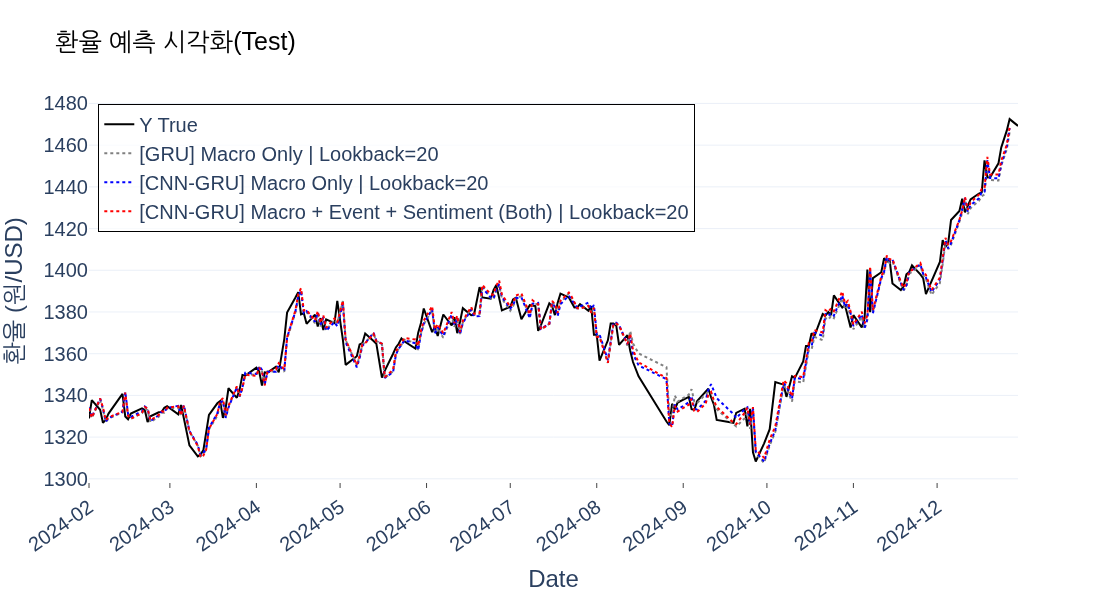

In [46]:
# Data Loading
file_location = os.path.join('.', 'Result', 'Prediction_KK.csv')
df = pd.read_csv(file_location)
# Filtering
df = df[df.Date>='2024-02-01'].reset_index().iloc[:,1:]
# Output
df_baseline1 = df.loc[(df.Lookback.isnull()) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'RandomWalk')].reset_index().iloc[:,1:]
df_baseline2 = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'RandomForest')].reset_index().iloc[:,1:]
df_baseline3 = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'XGBoost')].reset_index().iloc[:,1:]
df_baseline4 = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'GRU')].reset_index().iloc[:,1:]
df_baseline5 = df.loc[(df.Lookback == 10) & (df['Feature Case'] == 'Macro Only') & (df.Model == 'CNN-GRU')].reset_index().iloc[:,1:]
df_final = df.loc[(df.Lookback == 20) & (df['Feature Case'] == 'Macro + Event + Sentiment (Both)') & (df.Model == 'CNN-GRU')].reset_index().iloc[:,1:]
# Setting
df_line = pd.concat([df_baseline1[['Date', 'Y True']], 
                     # df_baseline2['Y Pred'], 
                     # df_baseline3['Y Pred'], 
                     df_baseline4['Y Pred'], 
                     df_baseline5['Y Pred'], 
                     df_final['Y Pred']], axis=1)
df_line.columns = ['Date', 'Y True', 'Y Pred(base4)', 'Y Pred(base5)', 'Y Pred(best)']
# df_line.columns = ['Date', 'Y True', 'Y Pred(base1)', 'Y Pred(base2)', 'Y Pred(base3)', 'Y Pred(base4)', 'Y Pred(base5)', 'Y Pred(best)']
df_line.Date = pd.to_datetime(df_line.Date)
df_line.set_index('Date', inplace=True)

# Visualization
my_names = {
    'Y True': 'Y True',
    # 'Y Pred(base1)': '[RandomWalk] Macro Only',
    # 'Y Pred(base2)': '[RandomForest] Macro Only | Lookback=20',
    # 'Y Pred(base3)': '[XGBoost] Macro Only | Lookback=20',
    'Y Pred(base4)': '[GRU] Macro Only | Lookback=20',
    'Y Pred(base5)': '[CNN-GRU] Macro Only | Lookback=20',
    'Y Pred(best)': '[CNN-GRU] Macro + Event + Sentiment (Both) | Lookback=20'
}
my_colors = {
    'Y True': 'black',       # 실제값은 검정
    'Y Pred(base4)': 'gray', # 베이스 모델은 회색
    'Y Pred(base5)': 'blue', 
    'Y Pred(best)': 'red'    # 베스트 모델은 빨강 강조
}
my_styles = {
    'Y True': 'solid',
    # 'Y Pred(base1)': 'dot',  # 점선
    # 'Y Pred(base2)': 'dot',
    # 'Y Pred(base3)': 'dot',
    'Y Pred(base4)': 'dot',
    'Y Pred(base5)': 'dot',
    'Y Pred(best)': 'dot'
}
plot_line(
    df_line, title='환율 예측 시각화(Test)', y_title='환율 (원/USD)', 
    legend_pos='top_left',
    name_map=my_names, 
    color_map=my_colors, 
    style_map=my_styles,
    save_local=False
)

# Result (Evaluation)

In [11]:
# Hyperparameters
METRIC_COLNAMES = ["RMSE", "MSPE", "MAE", "MAPE", "MedAE", "MedAPE"]
LABEL_COLNAME = "Model & Feature Case"
SCALING = True
TOP_RANKING = 10

In [12]:
# Data Loading
file_location = os.path.join('.', 'Result', 'PerformanceEvaluation_20260129_KK.xlsx')
df = pd.read_excel(file_location, sheet_name='Total')
df['Model & Feature Case'] = '[' + df.Model + ']  ' + df['Feature Case']
df = df[[col for col in df.columns if col != 'Radar Chart']]


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[GRU] Macro + Event + Sentiment (Both),0.9616,0.9708,0.9824,0.9839,1.0000,1.0000,2.5113
1,[CNN-GRU] Macro + Event + Sentiment (Direct),0.9811,0.9859,0.9834,0.9855,0.9458,0.9560,2.4596
2,[CNN-GRU] Macro + Sentiment (Both),1.0000,0.9992,1.0000,1.0000,0.8926,0.9207,2.4393
3,[LSTM] Macro + Event + Sentiment (Both),0.9850,0.9868,0.9848,0.9863,0.9443,0.9115,2.4270
4,[CNN-GRU] Macro + Sentiment (Indirect),0.9759,0.9818,0.9799,0.9825,0.9324,0.8977,2.3869
5,[CNN-GRU] Macro Only,0.9711,0.9781,0.9714,0.9751,0.8851,0.9545,2.3738
6,[CNN-GRU] Macro + Event,0.9467,0.9641,0.9650,0.9713,0.9598,0.9258,2.3719
7,[CNN-LSTM] Macro + Sentiment (Both),0.9907,0.9930,0.9899,0.9916,0.8673,0.8715,2.3502
8,[LSTM] Macro + Event,0.9778,0.9831,0.9989,0.9992,0.8505,0.8644,2.3259
9,[CNN-LSTM] Macro + Event,0.9747,0.9805,0.9873,0.9886,0.8395,0.8872,2.3120


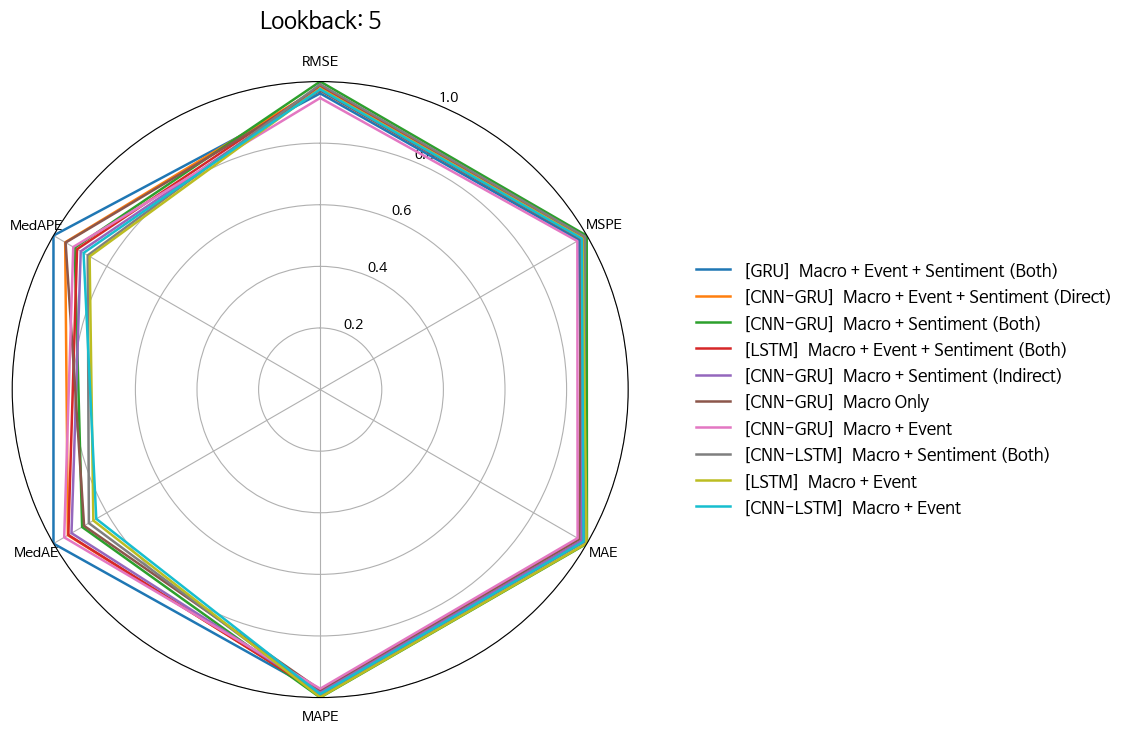


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[LSTM] Macro + Event + Sentiment (Both),0.9572,0.9655,0.9765,0.9769,1.0000,1.0000,2.4920
1,[CNN-GRU] Macro + Event + Sentiment (Indirect),0.9742,0.9799,0.9932,0.9928,0.9403,0.9635,2.4647
2,[CNN-GRU] Macro + Event + Sentiment (Both),1.0000,1.0000,0.9904,0.9911,0.9263,0.8914,2.4279
3,[CNN-LSTM] Macro + Sentiment (Indirect),0.9922,0.9941,1.0000,1.0000,0.8898,0.9129,2.4198
4,[LSTM] Macro + Event + Sentiment (Direct),0.9901,0.9937,0.9910,0.9926,0.9011,0.9132,2.4135
5,[CNN-GRU] Macro + Sentiment (Indirect),0.9551,0.9671,0.9586,0.9629,0.9542,0.9778,2.4073
6,[LSTM] Macro + Sentiment (Indirect),0.9631,0.9727,0.9901,0.9909,0.9170,0.9355,2.4025
7,[CNN-LSTM] Macro + Event + Sentiment (Both),0.9522,0.9696,0.9380,0.9482,0.9849,0.9687,2.3956
8,[CNN-LSTM] Macro + Event + Sentiment (Indirect),0.9648,0.9773,0.9657,0.9711,0.9331,0.9281,2.3781
9,[CNN-LSTM] Macro + Event + Sentiment (Direct),0.9862,0.9920,0.9810,0.9845,0.8868,0.8777,2.3531


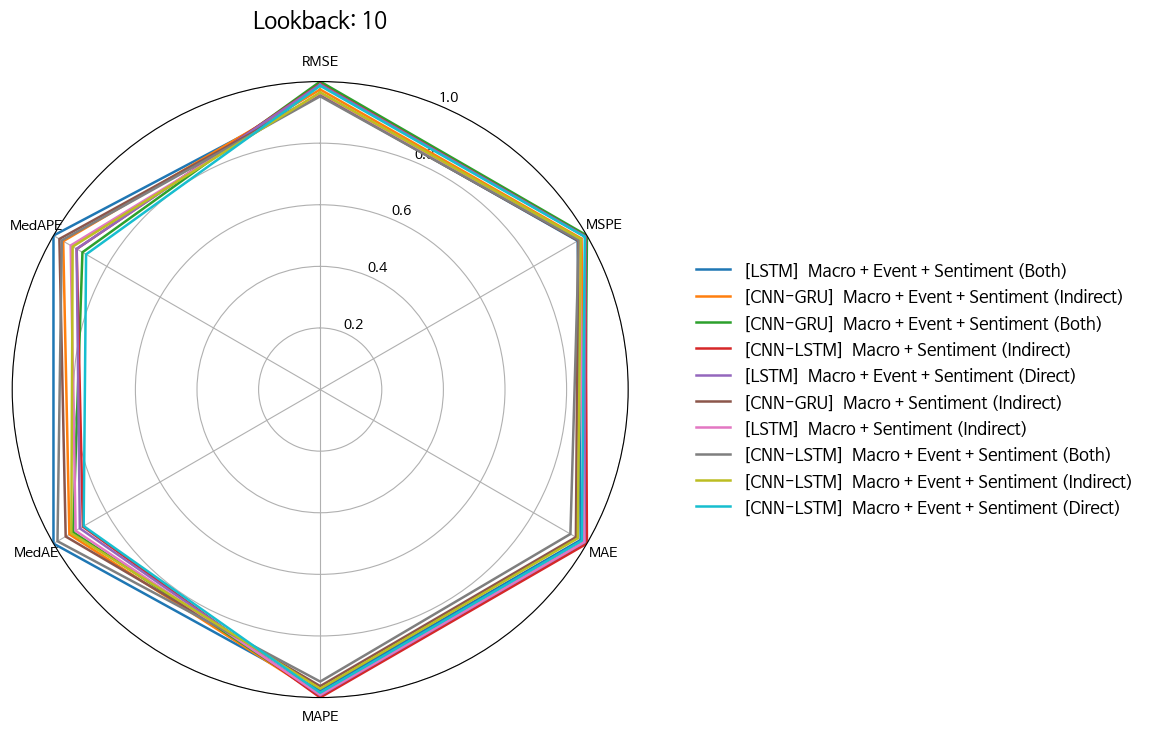


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[CNN-LSTM] Macro + Sentiment (Both),0.9749,0.9815,0.9925,0.9925,1.0000,1.0000,2.5476
1,[LSTM] Macro + Sentiment (Direct),0.9679,0.9761,0.9972,0.9958,0.9837,0.9630,2.4985
2,[CNN-GRU] Macro + Event + Sentiment (Both),1.0000,1.0000,1.0000,1.0000,0.9323,0.9466,2.4948
3,[LSTM] Macro Only,0.9751,0.9820,0.9851,0.9864,0.9455,0.9649,2.4606
4,[CNN-LSTM] Macro + Sentiment (Direct),0.9639,0.9742,0.9833,0.9849,0.9280,0.9162,2.3871
5,[LSTM] Macro + Event + Sentiment (Direct),0.9838,0.9917,0.9781,0.9828,0.9085,0.8807,2.3671
6,[CNN-LSTM] Macro + Event,0.9467,0.9649,0.9438,0.9522,0.9730,0.9428,2.3639
7,[LSTM] Macro + Sentiment (Both),0.9533,0.9669,0.9645,0.9686,0.9231,0.9286,2.3492
8,[CNN-GRU] Macro + Sentiment (Indirect),0.9574,0.9687,0.9887,0.9896,0.9153,0.8785,2.3445
9,[GRU] Macro + Event + Sentiment (Indirect),0.8949,0.9288,0.9391,0.9478,0.9733,0.9724,2.3091


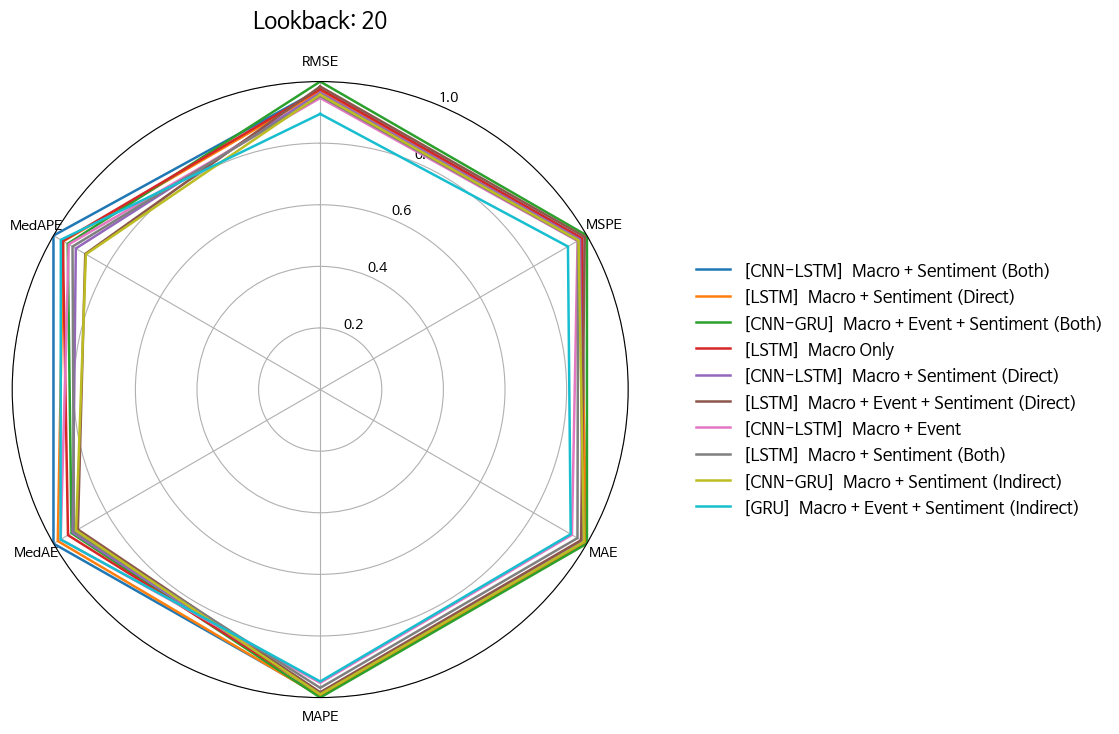


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[CNN-GRU] Macro + Event + Sentiment (Direct),0.9569,0.9662,1.0000,1.0000,1.0000,1.0000,2.5321
1,[LSTM] Macro + Event + Sentiment (Indirect),1.0000,1.0000,0.9923,0.9954,0.8305,0.8383,2.3127
2,[LSTM] Macro Only,0.9447,0.9580,0.9949,0.9961,0.8398,0.8892,2.2832
3,[CNN-GRU] Macro + Event + Sentiment (Indirect),0.9445,0.9591,0.9891,0.9918,0.8447,0.8553,2.2532
4,[GRU] Macro + Event + Sentiment (Both),0.9428,0.9571,0.9948,0.9957,0.8201,0.8399,2.2268
5,[CNN-GRU] Macro + Event + Sentiment (Both),0.9598,0.9701,0.9773,0.9819,0.7936,0.8278,2.1951
6,[CNN-LSTM] Macro + Sentiment (Direct),0.9683,0.9793,0.9733,0.9799,0.8017,0.7903,2.1821
7,[LSTM] Macro + Sentiment (Direct),0.9074,0.9341,0.9602,0.9673,0.8604,0.8429,2.1632
8,[LSTM] Macro + Event + Sentiment (Both),0.9851,0.9892,0.9841,0.9881,0.7399,0.7495,2.1409
9,[LSTM] Macro + Event + Sentiment (Direct),0.9393,0.9571,0.9733,0.9783,0.7887,0.7900,2.1302


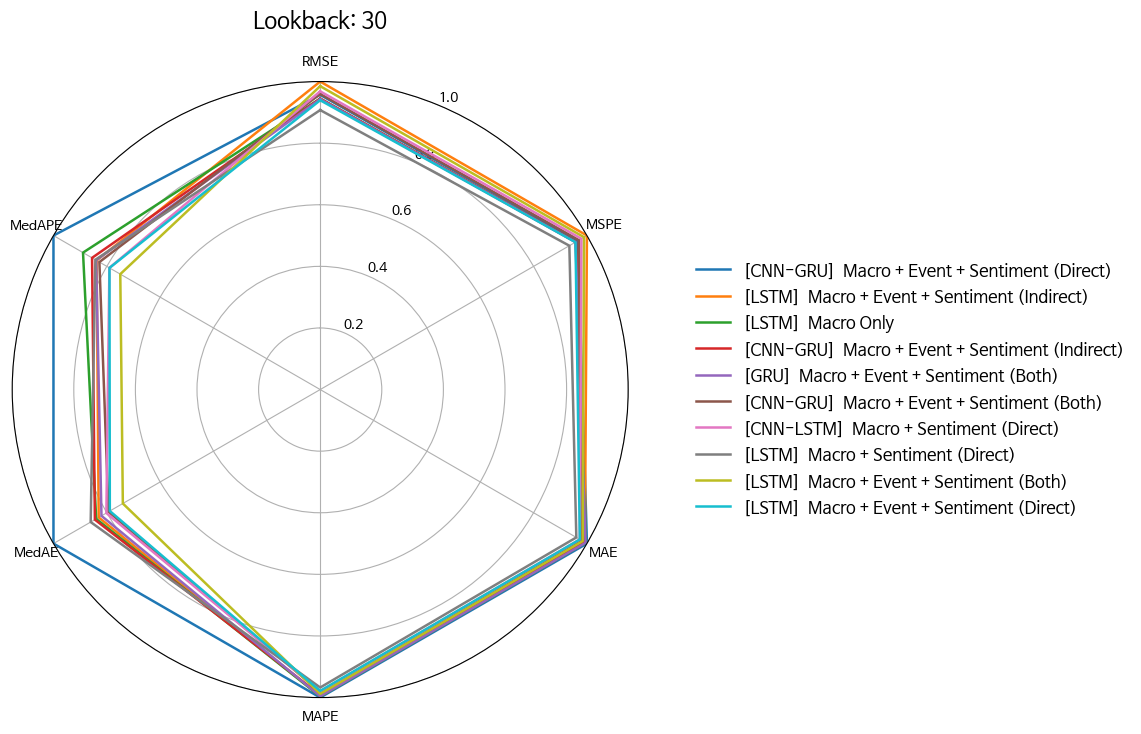


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[CNN-LSTM] Macro + Sentiment (Both),1.0000,1.0000,0.9869,0.9903,0.9181,0.9320,2.4513
1,[LSTM] Macro + Sentiment (Both),0.9984,0.9987,1.0000,1.0000,0.8991,0.8586,2.3921
2,[CNN-LSTM] Macro Only,0.9617,0.9781,0.9606,0.9706,0.9436,0.8697,2.3320
3,[CNN-LSTM] Macro + Sentiment (Direct),0.9636,0.9768,0.9594,0.9684,0.9035,0.9094,2.3298
4,[LSTM] Macro + Sentiment (Indirect),0.9454,0.9628,0.9745,0.9792,0.9099,0.8968,2.3198
5,[GRU] Macro + Event + Sentiment (Direct),0.8497,0.8994,0.9280,0.9418,0.9939,1.0000,2.2745
6,[CNN-LSTM] Macro + Event,0.9149,0.9421,0.9471,0.9568,0.9380,0.8920,2.2562
7,[LSTM] Macro + Event + Sentiment (Both),0.9719,0.9875,0.9265,0.9453,0.8349,0.8069,2.1640
8,[CNN-GRU] Macro + Sentiment (Both),0.9243,0.9535,0.9622,0.9714,0.8349,0.7969,2.1419
9,[CNN-LSTM] Macro + Sentiment (Indirect),0.9353,0.9608,0.9222,0.9406,0.8509,0.8308,2.1376


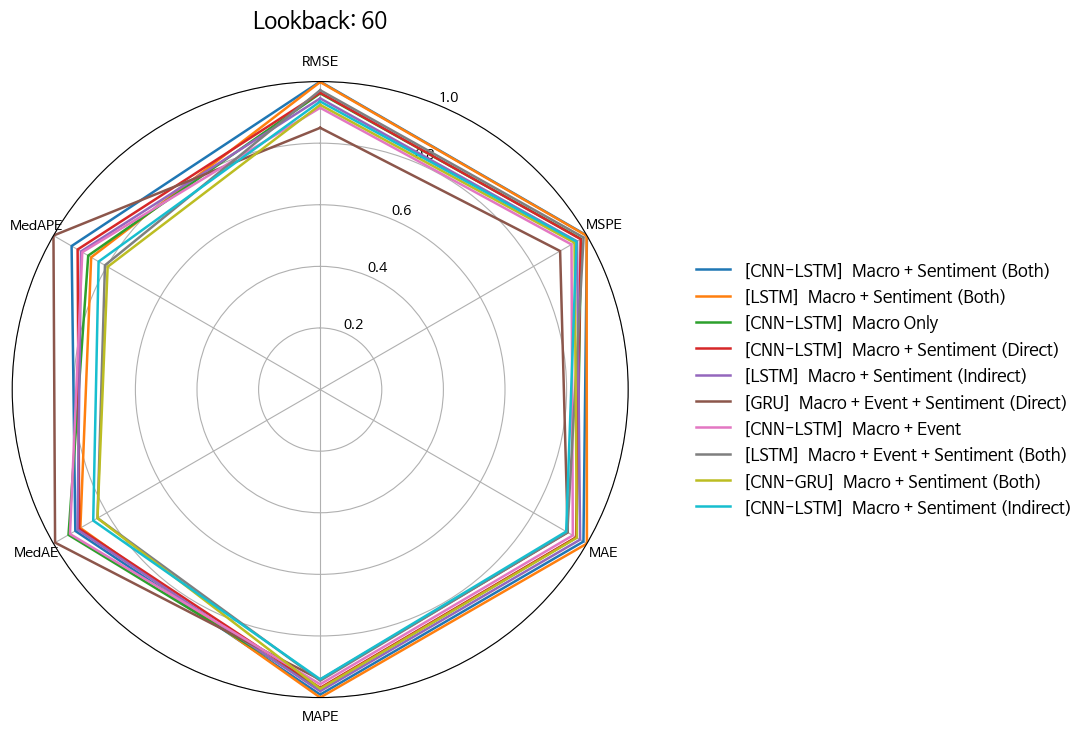


Top 10 by Radar Area:


,Model & Feature Case,RMSE,MSPE,MAE,MAPE,MedAE,MedAPE,Area of Radar
0,[CNN-LSTM] Macro Only,0.7518,1.0000,0.9014,1.0000,0.8837,0.9157,2.1373
1,[LSTM] Macro + Event,0.6912,0.9492,0.8497,0.9557,1.0000,1.0000,2.1311
2,[LSTM] Macro + Sentiment (Direct),0.6919,0.9463,0.8966,0.9955,0.8975,0.9605,2.0853
3,[CNN-GRU] Macro + Sentiment (Indirect),0.7042,0.9589,0.8528,0.9582,0.9227,0.9874,2.0787
4,[CNN-GRU] Macro + Event,0.7084,0.9635,0.8457,0.9514,0.8858,0.9435,2.0129
5,[XGBoost] Macro + Sentiment (Direct),0.9699,0.9752,1.0000,0.8806,0.7717,0.6393,1.9895
6,[CNN-GRU] Macro + Sentiment (Both),0.6888,0.9501,0.8487,0.9560,0.8661,0.9019,1.9497
7,[GRU] Macro + Event,0.6517,0.9157,0.7935,0.9064,0.9481,0.9954,1.9461
8,[XGBoost] Macro + Sentiment (Indirect),0.9386,0.9407,0.9380,0.8194,0.8283,0.7163,1.9392
9,[CNN-GRU] Macro + Event + Sentiment (Both),0.6807,0.9364,0.8748,0.9765,0.8305,0.8888,1.9333


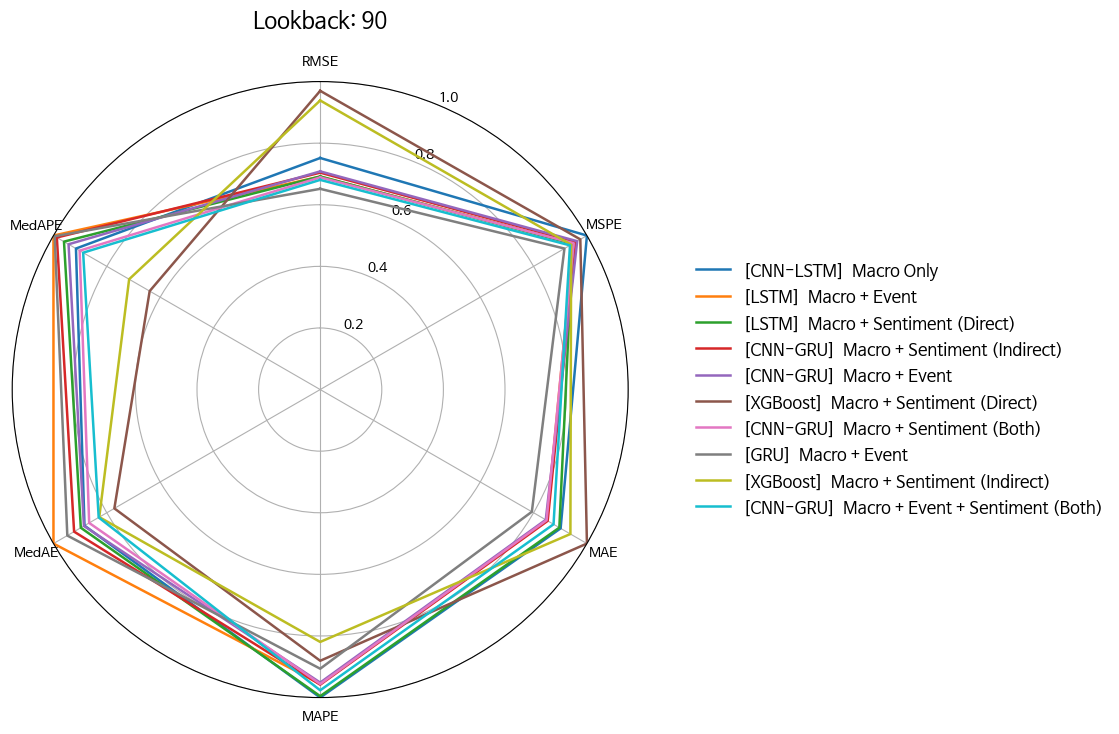

In [13]:
# Visualization
for lookback in sorted(df.Lookback.unique()):
    df_sub = df[df.Lookback == lookback]
    plot_radarchart(df_sub, metric_colnames=METRIC_COLNAMES,
                    label_colname=LABEL_COLNAME, 
                    scaling=SCALING, top_ranking=TOP_RANKING,
                    title='Lookback: '+str(np.unique(df_sub.Lookback)[0]))